In [1]:
import numpy as np

# Step 1: Data (flexible size)
data = np.array([[2, 1], [4, 3], [5, 4]], dtype=float)
n_rows = len(data)  # Number of data points
n_rows

3

In [4]:
# Center the data
mean = [0] * len(data[0])  # One mean per feature
for i in range(len(data[0])):  # Columns
    for j in range(n_rows):  # Rows
        mean[i] += data[j][i] / n_rows
centered = [[0] * len(data[0]) for _ in range(n_rows)]
for i in range(n_rows):
    for j in range(len(data[0])):
        centered[i][j] = data[i][j] - mean[j]
centered = np.array(centered)
print("Centered data:\n", centered)


Centered data:
 [[-1.66666667 -1.66666667]
 [ 0.33333333  0.33333333]
 [ 1.33333333  1.33333333]]


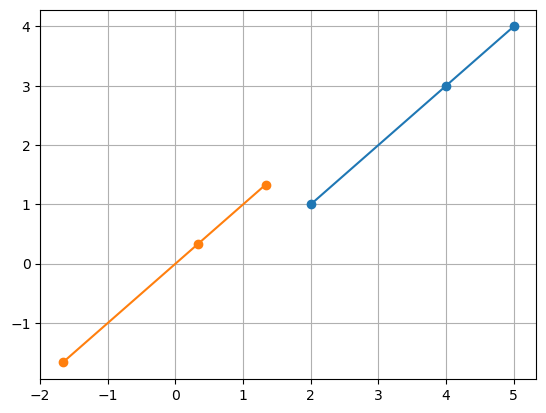

In [49]:
'''ref'''
import matplotlib.pyplot as plt

x = [row[0] for row in data]
y = [row[1] for row in data]
x_c = [row[0] for row in centered]
y_c = [row[1] for row in centered]

plt.plot(x, y, x_c, y_c, marker='o')
plt.grid()
plt.show()

In [51]:
# Step 2: Covariance matrix
n_features = len(data[0])  # Number of features
cov = [[0] * n_features for _ in range(n_features)]
for i in range(n_features):
    for j in range(n_features):
        for k in range(n_rows):
            cov[i][j] += centered[k][i] * centered[k][j] / (n_rows - 1)
        cov[i][j] = round(cov[i][j], 2)
cov = np.array(cov)
print("Covariance matrix:\n", cov)


Covariance matrix:
 [[2.33 2.33]
 [2.33 2.33]]


In [52]:
# Step 3: Eigenvalues & Eigenvectors
a, b, c, d = cov[0][0], cov[0][1], cov[1][0], cov[1][1]
coeff_a = 1
coeff_b = -(a + d)
coeff_c = a * d - b * c
disc = coeff_b**2 - 4 * coeff_a * coeff_c
lambda1 = (-coeff_b + disc**0.5) / (2 * coeff_a)
lambda2 = (-coeff_b - disc**0.5) / (2 * coeff_a)
eigenvalues = [lambda1, lambda2]
print("Eigenvalues:", eigenvalues)

# Pick largest eigenvalue
if lambda1 > lambda2:
    max_lambda = lambda1
else:
    max_lambda = lambda2
print("Largest eigenvalue:", max_lambda)

# Eigenvector for largest eigenvalue
cov_minus_lambda = [[0] * n_features for _ in range(n_features)]
for i in range(n_features):
    for j in range(n_features):
        cov_minus_lambda[i][j] = cov[i][j] - (max_lambda if i == j else 0)
v = [0] * n_features
v[0] = 1
v[1] = -cov_minus_lambda[0][0] / cov_minus_lambda[0][1] * v[0]  # Fixed division
v = np.array(v)
print("Eigenvector for largest λ:", v)


Eigenvalues: [4.66, 0.0]
Largest eigenvalue: 4.66
Eigenvector for largest λ: [1. 1.]


In [56]:
m = max(eigenvalues)
m

4.66

In [57]:
projected = [0] * n_rows
for i in range(n_rows):
    for j in range(n_features):
        projected[i] += centered[i][j] * v[j]
print("Projected data (1D):", projected)


Projected data (1D): [-3.3333333333333335, 0.6666666666666665, 2.6666666666666665]
